In [1]:
# ============================================================
# STAND-ALONE PATCH:
#   Produce 8 PDFs total:
#     - 2 delay groups detected from NPZ/JSON names: delay2 and delay5
#     - 4 configuration-model classes (mode tokens) per delay group
#       => 2 * 4 = 8 PDFs (skip any missing combinations)
#
#   All plotting/aggregation behavior remains the same:
#     - k-fold mean±std per group
#     - same 3x3 panel layout (A4 landscape)
#     - inline display + prints per PDF
#     - NL baseline dotted curve reused everywhere
# ============================================================

import os
import re
import json
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------
# USER CONFIG (override by defining these before running this cell/script)
# -----------------------------
ROOT = globals().get("ROOT", os.environ.get("ROOT", "."))  # directory containing .npz/.json
OUT_PDF = globals().get("OUT_PDF", os.environ.get("OUT_PDF", os.path.join(os.getcwd(), "gTRQC_EARLY_Overlay_Peak_AUC_grid.pdf")))
EARLY_TMAX = float(globals().get("EARLY_TMAX", os.environ.get("EARLY_TMAX", "1.0")))

# If you want different groups, edit these:
DELAY_CLASSES = ["delay2", "delay5"]
MODE_CLASSES = [
    "modefixed_projector_signed",
    "modefixed_projector_unsigned",
    "modeinstantaneous_projector_unsigned",
    "modeinstantaneous_projector_signed",
]

FILL_ALPHA = 0.2   # 80% transparency shadow
EXPORT_DPI = 300

# ============================================================
# FALLBACK DEFINITIONS (only used if your environment didn't already define them)
# ============================================================

if "trace_distance_to_mix" not in globals():
    def trace_distance_to_mix(rho_hist: np.ndarray) -> np.ndarray:
        """
        Compute D(rho, I/d) = 0.5 || rho - I/d ||_1 for each rho in rho_hist.
        Supports rho_hist shapes:
          - (T, d, d)
          - (T, d*d)  -> reshaped to (T, d, d) if possible
        """
        R = np.asarray(rho_hist)
        if R.ndim == 3 and R.shape[-1] == R.shape[-2]:
            T, d, _ = R.shape
            Rm = R
        elif R.ndim == 2:
            T, n = R.shape
            d = int(round(np.sqrt(n)))
            if d * d != n:
                raise ValueError(f"rho_hist has shape {R.shape}; cannot infer square matrix dimension.")
            Rm = R.reshape(T, d, d)
        else:
            raise ValueError(f"rho_hist must have shape (T,d,d) or (T,d*d); got {R.shape}")

        I_over_d = (np.eye(d, dtype=np.complex128) / float(d))
        out = np.empty((T,), dtype=float)
        for k in range(T):
            rho = np.asarray(Rm[k], dtype=np.complex128)
            delta = rho - I_over_d
            # Hermitian symmetrization for numerical stability
            delta = 0.5 * (delta + delta.conj().T)
            eigs = np.linalg.eigvalsh(delta)
            out[k] = 0.5 * float(np.sum(np.abs(eigs)))
        return out

if "run_id_str" not in globals():
    def run_id_str(M: Any, gq: Any, delay: Any, kernel: Any) -> str:
        gq_s = None if gq is None else int(bool(gq))
        return f"M={M}, gq={gq_s}, delay={delay}, kernel={kernel}"

if "find_baseline_npz" not in globals():
    def find_baseline_npz(root: str) -> Optional[str]:
        """
        Find an NPZ containing the nonlinear baseline trajectory:
          keys: 'nl_times' and 'nl_rho_hist'
        Preference: filenames containing 'baseline' or 'nonlinear' (but still verifies keys).
        """
        root = os.path.abspath(root)
        candidates: List[str] = []
        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if not fn.lower().endswith(".npz"):
                    continue
                p = os.path.join(dirpath, fn)
                lo = fn.lower()
                score = 0
                if "baseline" in lo:
                    score += 2
                if "nonlinear" in lo or "nl_" in lo:
                    score += 1
                candidates.append((score, p))
        # sort by score desc, then path
        candidates_sorted = [p for _, p in sorted(candidates, key=lambda x: (-x[0], x[1]))]

        for p in candidates_sorted:
            try:
                with np.load(p, allow_pickle=False) as Z:
                    if ("nl_times" in Z.files) and ("nl_rho_hist" in Z.files):
                        return p
            except Exception:
                continue
        return None

if "extract_runs" not in globals():
    def _safe_json_load(path: str) -> Dict[str, Any]:
        try:
            with open(path, "r", encoding="utf-8") as f:
                obj = json.load(f)
            return obj if isinstance(obj, dict) else {}
        except Exception:
            return {}

    def _first_present(dcts: List[Dict[str, Any]], keys: List[str]) -> Any:
        for d in dcts:
            if not isinstance(d, dict):
                continue
            for k in keys:
                if k in d and d[k] is not None:
                    return d[k]
        return None

    def _coerce_int(x: Any) -> Optional[int]:
        if x is None:
            return None
        if isinstance(x, (int, np.integer)):
            return int(x)
        if isinstance(x, float) and np.isfinite(x) and float(x).is_integer():
            return int(x)
        if isinstance(x, str):
            m = re.search(r"(\d+)", x)
            if m:
                try:
                    return int(m.group(1))
                except Exception:
                    return None
        return None

    def _coerce_bool01(x: Any) -> Optional[bool]:
        if x is None:
            return None
        if isinstance(x, (bool, np.bool_)):
            return bool(x)
        if isinstance(x, (int, np.integer)):
            return bool(int(x))
        if isinstance(x, str):
            s = x.strip().lower()
            if s in ("1", "true", "yes", "y", "on"):
                return True
            if s in ("0", "false", "no", "n", "off"):
                return False
        return None

    def _npz_get_any(Z: Any, keys: List[str]) -> Optional[np.ndarray]:
        for k in keys:
            if k in Z.files:
                return np.asarray(Z[k])
        return None

    def _infer_from_name(path: str) -> Dict[str, Any]:
        lo = os.path.basename(path).lower()
        out: Dict[str, Any] = {}

        mM = re.search(r"(?:^|[_\-])m(?:=)?(\d+)(?:[_\-]|$)", lo)
        if mM:
            out["M"] = int(mM.group(1))

        mgq = re.search(r"gq(?:=)?([01])", lo)
        if mgq:
            out["geometry_quantum"] = bool(int(mgq.group(1)))

        mdel = re.search(r"delay[^0-9]*(\d+)", lo)
        if mdel:
            out["delay_steps"] = int(mdel.group(1))

        mk = re.search(r"kernel[^a-z0-9]*([a-z0-9]+)", lo)
        if mk:
            out["kernel"] = mk.group(1)

        # mode token from name (if any)
        for tok in MODE_CLASSES:
            if tok.lower() in lo:
                out.setdefault("mode", tok)
                break

        return out

    def extract_runs(root: str) -> List[Dict[str, Any]]:
        """
        Stand-alone run extractor.

        Required in each run NPZ:
          - 'times' (or close variant)
          - 'trace_distance_to_nonlinear' (or close variant)

        Produces run dict fields used by the plotting code:
          - times, td_to_nonlinear
          - optional: residual_norm, trace, td_to_ref, d_mix_g, d_mix_nl
          - parsed: M, geometry_quantum, delay_steps, kernel, meta, summary, label, npz_path, json_path
        """
        root = os.path.abspath(root)
        runs: List[Dict[str, Any]] = []

        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if not fn.lower().endswith(".npz"):
                    continue
                npz_path = os.path.join(dirpath, fn)

                # Attempt to locate a sibling JSON
                stem = os.path.splitext(npz_path)[0]
                json_path = None
                for cand in (
                    stem + ".json",
                    stem + "_summary.json",
                    stem + ".summary.json",
                    stem + "_metrics.json",
                ):
                    if os.path.isfile(cand):
                        json_path = cand
                        break
                if json_path is None:
                    # last resort: any json with same stem prefix
                    try:
                        for g in sorted([p for p in os.listdir(dirpath) if p.lower().endswith(".json")]):
                            if os.path.splitext(g)[0] == os.path.splitext(fn)[0]:
                                json_path = os.path.join(dirpath, g)
                                break
                    except Exception:
                        json_path = None

                jdata = _safe_json_load(json_path) if json_path else {}
                meta = jdata.get("meta", {}) if isinstance(jdata.get("meta", {}), dict) else {}
                summary = jdata.get("summary", None)
                summary = summary if isinstance(summary, dict) else (jdata if isinstance(jdata, dict) else {})

                name_infer = _infer_from_name(npz_path)

                # Pull common fields from JSON/meta/summary/name
                M = _coerce_int(_first_present([meta, summary, jdata, name_infer], ["M", "m", "bond_dim"]))
                gq = _coerce_bool01(_first_present([meta, summary, jdata, name_infer], ["geometry_quantum", "gq", "geom_quantum"]))
                delay = _coerce_int(_first_present([meta, summary, jdata, name_infer], ["delay_steps", "delay"]))
                kernel = _first_present([meta, summary, jdata, name_infer], ["kernel", "kernel_name"])

                # mode string (keep as-is if present)
                mode = _first_present([meta, summary, jdata, name_infer], ["mode", "rate_mode"])
                if isinstance(mode, str) and mode.strip():
                    meta = dict(meta)
                    meta.setdefault("mode", mode)

                label = _first_present([summary, jdata], ["label", "run_label"])
                if not isinstance(label, str) or not label.strip():
                    label = os.path.basename(stem)

                # Load arrays from NPZ
                try:
                    with np.load(npz_path, allow_pickle=False) as Z:
                        # Skip baseline NPZs (they won't have required run arrays)
                        if ("nl_times" in Z.files) and ("nl_rho_hist" in Z.files) and ("times" not in Z.files):
                            continue

                        times = _npz_get_any(Z, ["times", "t", "ts", "time"])
                        td_nl = _npz_get_any(
                            Z,
                            [
                                "td_to_nonlinear",
                                "trace_distance_to_nonlinear",
                                "td_nonlinear",
                                "td_nl",
                            ],
                        )
                        if times is None or td_nl is None:
                            continue

                        times = np.asarray(times, dtype=float).ravel()
                        td_nl = np.asarray(td_nl, dtype=float).ravel()

                        L = min(len(times), len(td_nl))
                        times = times[:L]
                        td_nl = td_nl[:L]

                        residual = _npz_get_any(Z, ["residual_norm", "residual", "res_norm"])
                        if residual is not None:
                            residual = np.asarray(residual, dtype=float).ravel()[:L]

                        tr = _npz_get_any(Z, ["trace", "tr", "Tr"])
                        if tr is not None:
                            tr = np.asarray(tr, dtype=float).ravel()[:L]

                        td_ref = _npz_get_any(Z, ["td_to_ref", "trace_distance_to_ref", "td_ref"])
                        if td_ref is not None:
                            td_ref = np.asarray(td_ref, dtype=float).ravel()[:L]

                        d_mix_g = _npz_get_any(Z, ["d_mix_g", "td_to_mix", "trace_distance_to_mix"])
                        if d_mix_g is not None:
                            d_mix_g = np.asarray(d_mix_g, dtype=float).ravel()[:L]
                        else:
                            rho_m = _npz_get_any(Z, ["rho_m_hist", "rho_joint_hist", "rho_hist"])
                            if rho_m is not None:
                                try:
                                    d_mix_g = trace_distance_to_mix(np.asarray(rho_m, dtype=np.complex128))[:L]
                                except Exception:
                                    d_mix_g = None

                        d_mix_nl = _npz_get_any(Z, ["d_mix_nl", "nl_d_mix", "nl_td_to_mix"])
                        if d_mix_nl is not None:
                            d_mix_nl = np.asarray(d_mix_nl, dtype=float).ravel()[:L]
                        else:
                            rho_nl = _npz_get_any(Z, ["nl_rho_hist", "rho_nl_hist", "rho_nonlinear_hist"])
                            if rho_nl is not None:
                                try:
                                    d_mix_nl = trace_distance_to_mix(np.asarray(rho_nl, dtype=np.complex128))[:L]
                                except Exception:
                                    d_mix_nl = None

                except Exception:
                    continue

                # Early mask + early arrays (for baseline fallback compatibility)
                early_mask = (times >= 0.0) & (times <= float(EARLY_TMAX) + 1e-12)
                t_early = times[early_mask]
                d_mix_nl_early = (d_mix_nl[early_mask] if d_mix_nl is not None else None)

                # scalar finals (best-effort)
                td_nl_final_full = float(td_nl[-1]) if td_nl.size else None
                td_nl_final_early = float(td_nl[early_mask][-1]) if np.any(early_mask) else None

                residual_final = None
                if residual is not None and residual.size:
                    residual_final = float(residual[-1])
                else:
                    rf = _first_present([summary, jdata], ["residual_final"])
                    try:
                        residual_final = float(rf) if rf is not None else None
                    except Exception:
                        residual_final = None

                def _get_float_from_json(key: str) -> Optional[float]:
                    v = _first_present([summary, jdata], [key])
                    if v is None:
                        return None
                    try:
                        fv = float(v)
                        return fv if np.isfinite(fv) else None
                    except Exception:
                        return None

                run: Dict[str, Any] = {
                    "npz_path": npz_path,
                    "json_path": json_path,
                    "meta": meta,
                    "summary": summary,
                    "label": label,
                    "M": M,
                    "geometry_quantum": gq,
                    "delay_steps": delay,
                    "kernel": kernel,
                    "times": times,
                    "td_to_nonlinear": td_nl,
                    "residual_norm": residual,
                    "trace": tr,
                    "td_to_ref": td_ref,
                    "d_mix_g": d_mix_g,
                    "d_mix_nl": d_mix_nl,
                    "t_early": t_early,
                    "d_mix_nl_early": d_mix_nl_early,
                    "td_nl_final_early": td_nl_final_early,
                    "td_nl_final_full": td_nl_final_full,
                    "residual_final": residual_final,
                    "Srel_final": _get_float_from_json("Srel_final"),
                    "dK_absmean_final": _get_float_from_json("dK_absmean_final"),
                    "dK_absmax_final": _get_float_from_json("dK_absmax_final"),
                    "KL_final": _get_float_from_json("KL_final"),
                    "TV_final": _get_float_from_json("TV_final"),
                }

                runs.append(run)

        return runs

# ============================================================
# BASELINE CURVE (dotted black) for D(NL, I/d) — compute once, reuse everywhere
# ============================================================
runs_all = extract_runs(ROOT)
if not runs_all:
    raise RuntimeError(
        f"No convergence runs found under ROOT={os.path.abspath(ROOT)}. "
        "Expected NPZs containing keys: 'times' (or variant) and 'trace_distance_to_nonlinear' (or variant)."
    )

baseline_npz = find_baseline_npz(ROOT)
baseline_t_early = None
baseline_dmix_early = None

if baseline_npz is not None:
    try:
        with np.load(baseline_npz, allow_pickle=False) as Z:
            bt = np.asarray(Z["nl_times"], dtype=float)
            brho = np.asarray(Z["nl_rho_hist"], dtype=np.complex128)
        bL = min(len(bt), len(brho))
        bt = bt[:bL]
        brho = brho[:bL]
        bm = (bt >= 0.0) & (bt <= float(EARLY_TMAX) + 1e-12)
        if np.any(bm):
            baseline_t_early = bt[bm]
            baseline_dmix_early = trace_distance_to_mix(brho)[bm]
    except Exception:
        baseline_t_early = None
        baseline_dmix_early = None

# If no standalone baseline, use first run’s nl history (if present)
if baseline_t_early is None or baseline_dmix_early is None:
    r0 = runs_all[0]
    if r0.get("d_mix_nl_early") is not None:
        baseline_t_early = r0["t_early"]
        baseline_dmix_early = r0["d_mix_nl_early"]

# ============================================================
# MODE-CLASS MATCHING (from NPZ/JSON filenames + mode fields) — same as before
# ============================================================
def _class_variants(token: str) -> List[str]:
    t = str(token).strip()
    out = {t.lower()}
    if t.lower().startswith("mode") and (not t.lower().startswith("mode_")):
        out.add(("mode_" + t[4:]).lower())
        out.add(t[4:].lower())
    if t.lower().startswith("mode_"):
        out.add(("mode" + t[5:]).lower())
        out.add(t[5:].lower())
    return sorted(out)

def _run_matches_class(r: Dict[str, Any], class_token: str) -> bool:
    variants = _class_variants(class_token)

    meta = r.get("meta", {}) or {}
    summ = r.get("summary", {}) or {}

    hay = " ".join(
        [
            str(r.get("npz_path", "")),
            str(r.get("json_path", "")),
            str(r.get("label", "")),
            str(summ.get("label", "")),
            str(meta.get("mode", "")),
            str(meta.get("rate_mode", "")),
            str(summ.get("mode", "")),
            str(summ.get("rate_mode", "")),
        ]
    ).lower()
    return any(v in hay for v in variants)

# ============================================================
# DELAY MATCHING (from NPZ/JSON filenames + delay fields)
# ============================================================
def _delay_int_from_token(token: str) -> Optional[int]:
    m = re.search(r"delay[^0-9]*(\d+)", str(token).lower())
    if m:
        try:
            return int(m.group(1))
        except Exception:
            return None
    # fallback: any digits
    m2 = re.search(r"(\d+)", str(token))
    return int(m2.group(1)) if m2 else None

def _coerce_int(x: Any) -> Optional[int]:
    if x is None:
        return None
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and np.isfinite(x) and float(x).is_integer():
        return int(x)
    if isinstance(x, str):
        m = re.search(r"(\d+)", x)
        if m:
            try:
                return int(m.group(1))
            except Exception:
                return None
    return None

def _run_matches_delay(r: Dict[str, Any], delay_token: str) -> bool:
    d = _delay_int_from_token(delay_token)
    if d is None:
        return False

    meta = r.get("meta", {}) or {}
    summ = r.get("summary", {}) or {}

    # 1) prefer explicit fields
    for c in [
        r.get("delay_steps", None),
        meta.get("delay_steps", None),
        meta.get("delay", None),
        summ.get("delay_steps", None),
        summ.get("delay", None),
    ]:
        dc = _coerce_int(c)
        if dc is not None and int(dc) == int(d):
            return True

    # 2) filename/path regex (avoid delay2 matching delay20)
    hay = " ".join(
        [
            str(r.get("npz_path", "")),
            str(r.get("json_path", "")),
            str(r.get("label", "")),
            str(summ.get("label", "")),
        ]
    ).lower()
    pat = rf"delay[^0-9]*{int(d)}(?!\d)"
    return re.search(pat, hay) is not None

def _out_pdf_for_delay_mode(out_pdf: str, delay_token: str, mode_token: str) -> str:
    prefix = "gTRQC Thermodynamic-Limit ONE-PAGE Metrics"
    out_dir = os.path.dirname(os.path.abspath(out_pdf)) or os.getcwd()

    safe_delay = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", str(delay_token)).strip("_")
    safe_mode = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", str(mode_token)).strip("_")
    safe_prefix = re.sub(r"[^A-Za-z0-9_\-\. ]+", "", prefix).strip()

    return os.path.join(out_dir, f"{safe_prefix}_{safe_delay}_{safe_mode}.pdf")

# ============================================================
# GROUPING/AGGREGATION HELPERS (unchanged)
# ============================================================
def _get_mode_tag(r: Dict[str, Any]) -> str:
    meta = r.get("meta", {}) or {}
    summ = r.get("summary", {}) or {}
    mode = meta.get("mode", None)
    if not isinstance(mode, str):
        mode = meta.get("rate_mode", None)
    if not isinstance(mode, str):
        mode = summ.get("rate_mode", None)
    if not isinstance(mode, str):
        mode = summ.get("mode", None)
    return str(mode) if isinstance(mode, str) and mode.strip() else "mode=?"

def _group_key(r: Dict[str, Any]) -> Tuple[str, Optional[int], Optional[int], Optional[int], Optional[str]]:
    mode = _get_mode_tag(r)
    M = r.get("M", None)
    gq = r.get("geometry_quantum", None)
    delay = r.get("delay_steps", None)
    kernel = r.get("kernel", None)
    gq_int = (int(bool(gq)) if gq is not None else None)
    return (mode, M, gq_int, delay, kernel)

def _align_to_ref(t_ref: np.ndarray, t: np.ndarray, y: np.ndarray) -> np.ndarray:
    t_ref = np.asarray(t_ref, dtype=float)
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if t.shape == t_ref.shape and np.allclose(t, t_ref, atol=1e-12, rtol=0.0):
        return y.astype(float, copy=False)
    return np.interp(t_ref, t, y).astype(float)

def _stack_mean_std(rs: List[Dict[str, Any]], field: str, t_ref: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Ys = []
    for rr in rs:
        y = rr.get(field, None)
        if y is None:
            raise KeyError(f"Missing field '{field}' in a fold; cannot aggregate.")
        y = np.asarray(y, dtype=float)
        Ys.append(_align_to_ref(t_ref, np.asarray(rr["times"], float), y))
    Y = np.vstack(Ys)
    mean = np.mean(Y, axis=0)
    std = (np.std(Y, axis=0, ddof=1) if Y.shape[0] > 1 else np.zeros_like(mean))
    return mean, std

def _stack_optional_mean_std(rs: List[Dict[str, Any]], field: str, t_ref: np.ndarray) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    for rr in rs:
        if rr.get(field, None) is None:
            return None
    return _stack_mean_std(rs, field, t_ref)

# ============================================================
# RENDER ONE PDF FOR ONE (delay, mode-class) COMBINATION
# ============================================================
def _render_one_pdf(delay_token: str, mode_token: str, runs: List[Dict[str, Any]], out_pdf: str) -> None:
    class_token = f"{mode_token} | {delay_token}"

    # Group runs
    _groups: Dict[Tuple[str, Optional[int], Optional[int], Optional[int], Optional[str]], List[Dict[str, Any]]] = {}
    for r in runs:
        _groups.setdefault(_group_key(r), []).append(r)

    def _g_sort_key(k: Tuple[str, Optional[int], Optional[int], Optional[int], Optional[str]]) -> Tuple:
        mode, M, gq, delay, kernel = k
        Mk = (1, 10**9) if M is None else (0, int(M))
        gqk = (2 if gq is None else int(gq))
        dk = (10**9 if delay is None else int(delay))
        kk = "" if kernel is None else str(kernel)
        return (str(mode), Mk[0], Mk[1], gqk, dk, kk)

    group_keys = sorted(_groups.keys(), key=_g_sort_key)

    groups: List[Dict[str, Any]] = []
    for k in group_keys:
        rs = _groups[k]
        rs_sorted = sorted(rs, key=lambda rr: len(rr["times"]))
        t_ref = np.asarray(rs_sorted[0]["times"], dtype=float)

        td_mean, td_std = _stack_mean_std(rs_sorted, "td_to_nonlinear", t_ref)

        res_ms = _stack_optional_mean_std(rs_sorted, "residual_norm", t_ref)
        tr_ms = _stack_optional_mean_std(rs_sorted, "trace", t_ref)
        tdref_ms = _stack_optional_mean_std(rs_sorted, "td_to_ref", t_ref)

        early_mask = (t_ref >= 0.0) & (t_ref <= float(EARLY_TMAX) + 1e-12)
        if not np.any(early_mask):
            continue

        dmixg_ms = _stack_optional_mean_std(rs_sorted, "d_mix_g", t_ref)
        dmixnl_ms = _stack_optional_mean_std(rs_sorted, "d_mix_nl", t_ref)

        mode, M, gq_int, delay, kernel = k
        gq_bool = (bool(gq_int) if gq_int is not None else None)

        def _scalar_agg(keyname: str) -> Tuple[Optional[float], Optional[float]]:
            vals = []
            for rr in rs_sorted:
                v = rr.get(keyname, None)
                if v is None:
                    continue
                try:
                    fv = float(v)
                    if np.isfinite(fv):
                        vals.append(fv)
                except Exception:
                    continue
            if not vals:
                return (None, None)
            mu = float(np.mean(vals))
            sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            return (mu, sd)

        lab = f"{mode} | " + run_id_str(M, gq_bool, delay, kernel)

        groups.append(
            {
                "key": k,
                "label": lab,
                "mode": mode,
                "M": M,
                "geometry_quantum": gq_bool,
                "delay_steps": delay,
                "kernel": kernel,
                "n_folds": len(rs_sorted),
                "times": t_ref,
                "t_early": t_ref[early_mask],
                "td_nl_mean": td_mean,
                "td_nl_std": td_std,
                "td_nl_early_mean": td_mean[early_mask],
                "td_nl_early_std": td_std[early_mask],
                "residual_mean": (res_ms[0] if res_ms is not None else None),
                "residual_std": (res_ms[1] if res_ms is not None else None),
                "trace_mean": (tr_ms[0] if tr_ms is not None else None),
                "trace_std": (tr_ms[1] if tr_ms is not None else None),
                "td_ref_mean": (tdref_ms[0] if tdref_ms is not None else None),
                "td_ref_std": (tdref_ms[1] if tdref_ms is not None else None),
                "d_mix_g_mean": (dmixg_ms[0] if dmixg_ms is not None else None),
                "d_mix_g_std": (dmixg_ms[1] if dmixg_ms is not None else None),
                "d_mix_nl_mean": (dmixnl_ms[0] if dmixnl_ms is not None else None),
                "d_mix_nl_std": (dmixnl_ms[1] if dmixnl_ms is not None else None),
                "residual_final_mean": _scalar_agg("residual_final")[0],
                "residual_final_std": _scalar_agg("residual_final")[1],
                "Srel_final_mean": _scalar_agg("Srel_final")[0],
                "Srel_final_std": _scalar_agg("Srel_final")[1],
                "KL_final_mean": _scalar_agg("KL_final")[0],
                "KL_final_std": _scalar_agg("KL_final")[1],
                "TV_final_mean": _scalar_agg("TV_final")[0],
                "TV_final_std": _scalar_agg("TV_final")[1],
                "dK_absmean_final_mean": _scalar_agg("dK_absmean_final")[0],
                "dK_absmean_final_std": _scalar_agg("dK_absmean_final")[1],
                "dK_absmax_final_mean": _scalar_agg("dK_absmax_final")[0],
                "dK_absmax_final_std": _scalar_agg("dK_absmax_final")[1],
                "td_nl_final_early_mean": float(td_mean[early_mask][-1]),
                "td_nl_final_early_std": float(td_std[early_mask][-1]),
                "td_nl_final_full_mean": float(td_mean[-1]) if td_mean.size else None,
                "td_nl_final_full_std": float(td_std[-1]) if td_std.size else None,
            }
        )

    if not groups:
        print(f"[INFO] No groups formed for '{class_token}' (nothing to plot).")
        return

    # -----------------------------
    # PRINT NUMERICAL RESULTS (same format as before)
    # -----------------------------
    print("\n=== ONE-PAGE Report — extracted run summaries ===")
    print(f"CLASS:       {class_token}")
    print(f"ROOT:        {os.path.abspath(ROOT)}")
    print(f"EARLY_TMAX:  {EARLY_TMAX:g}")
    print(f"Runs:        {len(runs)}")
    print(f"Groups:      {len(groups)}  (k-fold aggregated)")
    print(f"NL baseline: {baseline_npz if baseline_npz is not None else 'first run nl_rho_hist (fallback)'}")
    print("")
    hdr = "MODE                 M  gq  delay  kernel      tdNL(t*)±std        tdNL(final)±std      res_final±std"
    print(hdr)
    print("-" * len(hdr))

    def _fmt_pm(mu, sd, w=18, prec=4):
        if mu is None:
            return " " * w
        try:
            m = float(mu)
            s = float(sd) if sd is not None else 0.0
            if not np.isfinite(m) or not np.isfinite(s):
                return f"{'nan':>{w}}"
            txt = f"{m:.{prec}g} ± {s:.{prec}g}"
            return f"{txt:>{w}}"
        except Exception:
            return " " * w

    for g in groups:
        mode = str(g.get("mode", "mode=?"))[:20].ljust(20)
        M = g.get("M")
        gq = g.get("geometry_quantum")
        delay = g.get("delay_steps")
        kernel = g.get("kernel")
        print(
            f"{mode}  {str(M):>2}  {str(int(bool(gq)) if gq is not None else None):>2}  {str(delay):>5}  {str(kernel):<10}  "
            f"{_fmt_pm(g.get('td_nl_final_early_mean'), g.get('td_nl_final_early_std'), w=18, prec=4)}  "
            f"{_fmt_pm(g.get('td_nl_final_full_mean'), g.get('td_nl_final_full_std'), w=18, prec=4)}  "
            f"{_fmt_pm(g.get('residual_final_mean'), g.get('residual_final_std'), w=16, prec=4)}"
        )

    # -----------------------------
    # Plotting — same single-page layout (A4 landscape)
    # -----------------------------
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % 20) for i in range(len(groups))]

    fig = plt.figure(figsize=(11.69, 8.27))
    gs = fig.add_gridspec(3, 3)

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])
    ax02 = fig.add_subplot(gs[0, 2])
    ax10 = fig.add_subplot(gs[1, 0])
    ax11 = fig.add_subplot(gs[1, 1])
    ax12 = fig.add_subplot(gs[1, 2])
    ax20 = fig.add_subplot(gs[2, 0])
    ax21 = fig.add_subplot(gs[2, 1])
    ax22 = fig.add_subplot(gs[2, 2])

    ax00.set_title("trace_distance_to_nonlinear(t) — full (mean ± std over folds)")
    ax00.set_xlabel("t")
    ax00.set_ylabel("0.5||rho_gTRQC - rho_nonlinear||_1")
    ax00.grid(True, alpha=0.3)

    ax01.set_title(f"EARLY overlay (t <= {EARLY_TMAX:g}): mean ± std over folds")
    ax01.set_xlabel("t")
    ax01.set_ylabel("trace distance")
    ax01.set_xlim(0.0, float(EARLY_TMAX))
    ax01.set_ylim(0.0, 1.0)
    ax01.grid(True, alpha=0.3)

    ax02.set_title("residual_norm(t) (if present) — mean ± std over folds")
    ax02.set_xlabel("t")
    ax02.set_ylabel("residual_norm")
    ax02.grid(True, alpha=0.3)

    ax10.set_title("trace_distance_to_ref(t) (if present) — mean ± std over folds")
    ax10.set_xlabel("t")
    ax10.set_ylabel("0.5||rho - rho_ref||_1")
    ax10.grid(True, alpha=0.3)

    ax11.set_title("Tr(rho_joint)(t) (if present) — mean ± std over folds")
    ax11.set_xlabel("t")
    ax11.set_ylabel("Tr")
    ax11.grid(True, alpha=0.3)

    handles: List[Any] = []
    labels: List[str] = []

    for i, g in enumerate(groups):
        col = colors[i]

        t = np.asarray(g["times"], float)
        td_mu = np.asarray(g["td_nl_mean"], float)
        td_sd = np.asarray(g["td_nl_std"], float)

        h, = ax00.plot(t, td_mu, color=col, lw=2.2, ls="-")
        ax00.fill_between(t, td_mu - td_sd, td_mu + td_sd, color=col, alpha=FILL_ALPHA, linewidth=0.0)
        handles.append(h)
        labels.append(f"{g['label']} | k={g['n_folds']}")

        te = np.asarray(g["t_early"], float)
        td_e_mu = np.asarray(g["td_nl_early_mean"], float)
        td_e_sd = np.asarray(g["td_nl_early_std"], float)
        ax01.plot(te, td_e_mu, color=col, lw=2.2, ls="-")
        ax01.fill_between(te, td_e_mu - td_e_sd, td_e_mu + td_e_sd, color=col, alpha=FILL_ALPHA, linewidth=0.0)

        if g.get("d_mix_g_mean") is not None and g.get("d_mix_g_std") is not None:
            dm_mu = np.asarray(g["d_mix_g_mean"], float)
            dm_sd = np.asarray(g["d_mix_g_std"], float)
            em = (t >= 0.0) & (t <= float(EARLY_TMAX) + 1e-12)
            ax01.plot(t[em], dm_mu[em], color=col, lw=1.8, ls="--", alpha=0.92)
            ax01.fill_between(t[em], dm_mu[em] - dm_sd[em], dm_mu[em] + dm_sd[em], color=col, alpha=FILL_ALPHA, linewidth=0.0)

        if g.get("residual_mean") is not None and g.get("residual_std") is not None:
            rr_mu = np.asarray(g["residual_mean"], float)
            rr_sd = np.asarray(g["residual_std"], float)
            L = min(len(t), len(rr_mu))
            ax02.plot(t[:L], rr_mu[:L], color=col, lw=2.0, ls="-", alpha=0.80)
            ax02.fill_between(t[:L], rr_mu[:L] - rr_sd[:L], rr_mu[:L] + rr_sd[:L], color=col, alpha=FILL_ALPHA, linewidth=0.0)

        if g.get("td_ref_mean") is not None and g.get("td_ref_std") is not None:
            tdref_mu = np.asarray(g["td_ref_mean"], float)
            tdref_sd = np.asarray(g["td_ref_std"], float)
            L = min(len(t), len(tdref_mu))
            ax10.plot(t[:L], tdref_mu[:L], color=col, lw=2.0, ls="-", alpha=0.80)
            ax10.fill_between(t[:L], tdref_mu[:L] - tdref_sd[:L], tdref_mu[:L] + tdref_sd[:L], color=col, alpha=FILL_ALPHA, linewidth=0.0)

        if g.get("trace_mean") is not None and g.get("trace_std") is not None:
            tr_mu = np.asarray(g["trace_mean"], float)
            tr_sd = np.asarray(g["trace_std"], float)
            L = min(len(t), len(tr_mu))
            ax11.plot(t[:L], tr_mu[:L], color=col, lw=2.0, ls="-", alpha=0.80)
            ax11.fill_between(t[:L], tr_mu[:L] - tr_sd[:L], tr_mu[:L] + tr_sd[:L], color=col, alpha=FILL_ALPHA, linewidth=0.0)

    if baseline_t_early is not None and baseline_dmix_early is not None:
        ax01.plot(baseline_t_early, baseline_dmix_early, color="black", lw=2.2, ls=":", alpha=0.80)

    style_handles = [
        Line2D([0], [0], color="k", lw=2.2, ls="-", label="solid: mean D(gTRQC, nonlinear)"),
        Line2D([0], [0], color="k", lw=1.8, ls="--", label="dashed: mean D(gTRQC, I/d)"),
        Line2D([0], [0], color="k", lw=2.2, ls=":", label="dotted: D(nonlinear, I/d) baseline"),
    ]
    ax01.legend(handles=style_handles, loc="lower left", frameon=True, fontsize=8, title="Line styles", title_fontsize=9)

    def scatter_summary_groups(ax, y_mu_key: str, y_sd_key: str, title: str, ylabel: str) -> None:
        xs0, ys0, es0 = [], [], []
        xs1, ys1, es1 = [], [], []
        for g in groups:
            M = g.get("M", None)
            gq = g.get("geometry_quantum", None)
            mu = g.get(y_mu_key, None)
            sd = g.get(y_sd_key, None)
            if M is None or mu is None:
                continue
            try:
                mu = float(mu)
                sd = float(sd) if sd is not None else 0.0
            except Exception:
                continue
            if not np.isfinite(mu) or not np.isfinite(sd):
                continue
            if gq is True:
                xs1.append(int(M)); ys1.append(mu); es1.append(sd)
            else:
                xs0.append(int(M)); ys0.append(mu); es0.append(sd)

        if xs0:
            for x, y, e in zip(xs0, ys0, es0):
                ax.scatter([x], [y], s=45, color="C0", marker="o", edgecolor="k", linewidths=0.1, alpha=0.9)
                ax.fill_between([x - 0.15, x + 0.15], [y - e, y - e], [y + e, y + e], color="C0", alpha=FILL_ALPHA, linewidth=0.0)
        if xs1:
            for x, y, e in zip(xs1, ys1, es1):
                ax.scatter([x], [y], s=55, color="C1", marker="s", edgecolor="k", linewidths=0.1, alpha=0.9)
                ax.fill_between([x - 0.15, x + 0.15], [y - e, y - e], [y + e, y + e], color="C1", alpha=FILL_ALPHA, linewidth=0.0)

        xt = sorted(set(xs0 + xs1))
        if xt:
            ax.set_xticks(xt)
        ax.set_title(title)
        ax.set_xlabel("M")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    scatter_summary_groups(
        ax12,
        "td_nl_final_early_mean", "td_nl_final_early_std",
        f"td_to_nonlinear(t={EARLY_TMAX:g}) vs M  (o:gq0, s:gq1)  mean±std",
        "td_nonlinear(early-final)"
    )
    scatter_summary_groups(
        ax20,
        "residual_final_mean", "residual_final_std",
        "residual_norm_final vs M  (o:gq0, s:gq1)  mean±std",
        "residual_final"
    )
    scatter_summary_groups(
        ax21,
        "dK_absmean_final_mean", "dK_absmean_final_std",
        "dK_final_absmean vs M  (o:gq0, s:gq1)  mean±std",
        "dK_absmean_final"
    )

    for g in groups:
        M = g.get("M", None)
        if M is None:
            continue
        x = int(M)
        gq = g.get("geometry_quantum", None)

        kl_mu = g.get("KL_final_mean", None)
        kl_sd = g.get("KL_final_std", None)
        tv_mu = g.get("TV_final_mean", None)
        tv_sd = g.get("TV_final_std", None)

        s = 55 if gq else 45

        if kl_mu is not None and np.isfinite(float(kl_mu)):
            y = float(kl_mu)
            e = float(kl_sd) if (kl_sd is not None and np.isfinite(float(kl_sd))) else 0.0
            ax22.scatter([x], [y], s=s, color="C2", marker="s", edgecolor="k", linewidths=0.1, alpha=0.9)
            ax22.fill_between([x - 0.15, x + 0.15], [y - e, y - e], [y + e, y + e], color="C2", alpha=FILL_ALPHA, linewidth=0.0)

        if tv_mu is not None and np.isfinite(float(tv_mu)):
            y = float(tv_mu)
            e = float(tv_sd) if (tv_sd is not None and np.isfinite(float(tv_sd))) else 0.0
            ax22.scatter([x], [y], s=s, color="C3", marker="^", edgecolor="k", linewidths=0.1, alpha=0.9)
            ax22.fill_between([x - 0.15, x + 0.15], [y - e, y - e], [y + e, y + e], color="C3", alpha=FILL_ALPHA, linewidth=0.0)

    ax22.set_title("KL_geom_final (square) and TV_geom_final (triangle) vs M  mean±std (size↑ means gq=1)")
    ax22.set_xlabel("M")
    ax22.set_ylabel("value")
    xt = sorted(set([g["M"] for g in groups if g.get("M") is not None]))
    if xt:
        ax22.set_xticks(xt)
    ax22.grid(True, alpha=0.3)

    fig.suptitle(
        f"gTRQC Thermodynamic-Limit ONE-PAGE Metrics | class={class_token} | ROOT={os.path.abspath(ROOT)} | early t <= {EARLY_TMAX:g} | mean±std over folds",
        y=0.98,
    )
    fig.subplots_adjust(left=0.06, right=0.99, top=0.92, bottom=0.17, wspace=0.30, hspace=0.42)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=min(3, max(1, len(labels))),
        frameon=True,
        bbox_to_anchor=(0.5, 0.02),
    )

    os.makedirs(os.path.dirname(os.path.abspath(out_pdf)) or ".", exist_ok=True)
    with PdfPages(out_pdf) as pdf:
        pdf.savefig(fig, dpi=EXPORT_DPI, bbox_inches="tight")

    print("\nONE-PAGE PDF written:", out_pdf)
    print("Run files read (class):", len(runs))
    print("Model-groups plotted (k-fold mean±std):", len(groups))
    print("NL baseline source:", baseline_npz if baseline_npz is not None else "first run nl_rho_hist (fallback)")

    # Inline display (same behavior as before)
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()

    plt.close(fig)

# ============================================================
# CREATE UP TO 8 PDFs (2 delays × 4 mode-classes)
# ============================================================
created: Dict[Tuple[str, str], str] = {}

# Pre-filter by delay once
runs_by_delay: Dict[str, List[Dict[str, Any]]] = {}
for dtoken in DELAY_CLASSES:
    runs_by_delay[dtoken] = [r for r in runs_all if _run_matches_delay(r, dtoken)]
    if not runs_by_delay[dtoken]:
        print(f"[INFO] Delay-group '{dtoken}' not found in NPZ/JSON names — all 4 PDFs for this delay will be skipped.")

for dtoken in DELAY_CLASSES:
    for cls in MODE_CLASSES:
        runs_combo = [r for r in runs_by_delay.get(dtoken, []) if _run_matches_class(r, cls)]
        if not runs_combo:
            print(f"[INFO] Combo not found — skipping PDF: delay='{dtoken}', class='{cls}'.")
            continue

        out_pdf_combo = _out_pdf_for_delay_mode(OUT_PDF, dtoken, cls)
        _render_one_pdf(dtoken, cls, runs_combo, out_pdf_combo)
        created[(dtoken, cls)] = out_pdf_combo

print("\n=== PDF generation summary ===")
if not created:
    print("No PDFs created (none of the requested delay×class combinations were found in NPZ/JSON names).")
else:
    for (dtoken, cls), path in sorted(created.items(), key=lambda kv: (kv[0][0], kv[0][1])):
        print(f"- {dtoken} | {cls}: {path}")


RuntimeError: No convergence runs found under ROOT=/Users/h4/Desktop/gTRQC_extended/gTRQC_extended_03_1. Expected NPZs containing keys: 'times' (or variant) and 'trace_distance_to_nonlinear' (or variant).

[INFO] ROOT (input)      : .
[INFO] ROOT (abs)        : /Users/h4/Desktop/gTRQC_extended/gTRQC_extended_03_1
[INFO] NPZ files under ROOT (recursive): 75
[INFO] Extracted runs: 72
[INFO] All extracted runs are under ROOT_ABS.
[INFO] Baseline found: /Users/h4/Desktop/gTRQC_extended/gTRQC_extended_03_1/gTRQC_OCTA_SUITE_OCTA_NONLINEAR_BASELINE_fold0_delay1_kerneldelta_20260117_104347_141.npz
[INFO] delay1: runs matched = 72
[OK] Wrote PDF for delay1: /Users/h4/Desktop/gTRQC_extended/gTRQC_extended_03_1/gTRQC_EARLY_Overlay_Peak_AUC_grid_delay1.pdf


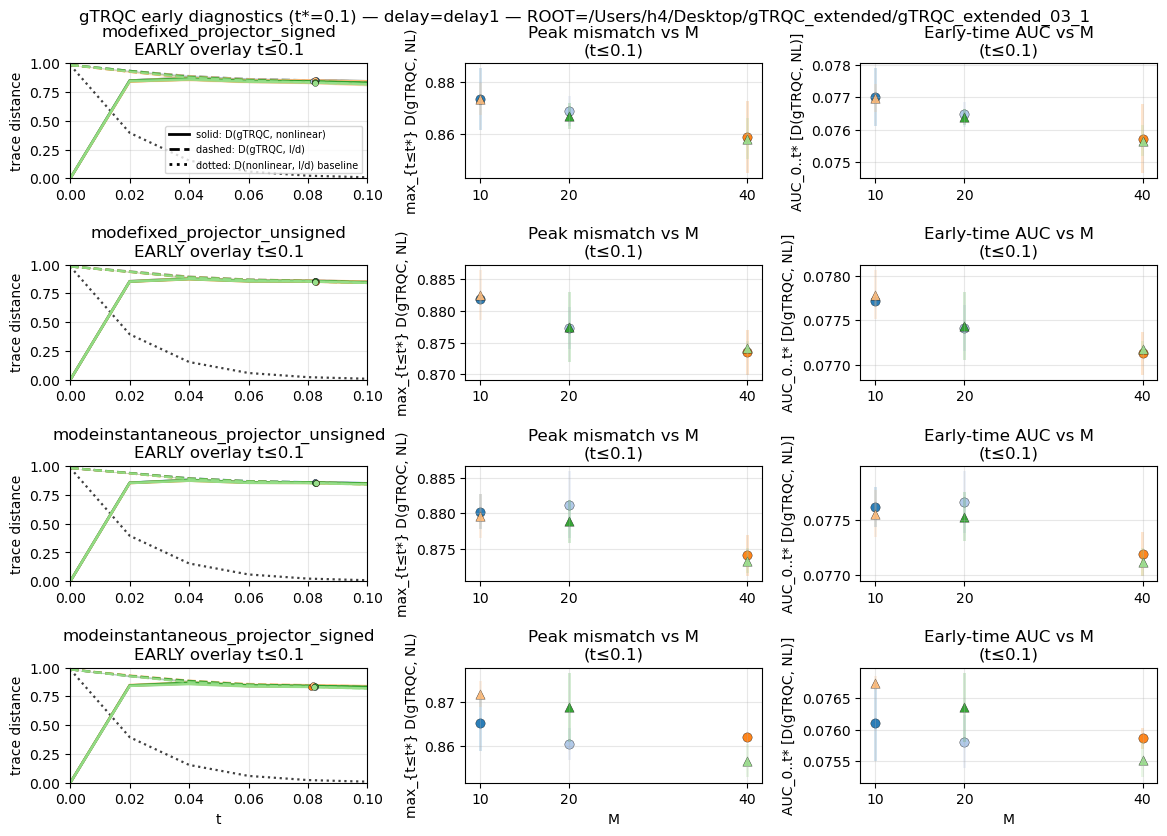


=== Summary ===
- delay1: /Users/h4/Desktop/gTRQC_extended/gTRQC_extended_03_1/gTRQC_EARLY_Overlay_Peak_AUC_grid_delay1.pdf


In [11]:
# ============================================================
# FIXED CODE 2 (delay2 + delay5) — matches Code 1 early-overlay behavior
#
# What was different (root cause):
#   In your previous Code 2, each group was built ONLY from folds that had d_mix_g.
#   That changes the SOLID mean curve (D(gTRQC, nonlinear)) because it excludes folds
#   missing d_mix_g — while Code 1 always averages the SOLID curve over *all* folds,
#   and only plots the DASHED curve if *every fold* has d_mix_g (optional mean/std).
#
# This version changes Code 2 so that:
#   - SOLID mean±std uses *all folds* in the group (matches Code 1)
#   - DASHED mean±std is computed only if *all folds* have d_mix_g; otherwise dashed is omitted
#   - (Optional) group key includes the resolved "mode tag", so Code 2 doesn't accidentally
#     merge distinct mode strings that Code 1 would keep separate.
#
# Also adds explicit ROOT diagnostics:
#   - Prints the absolute ROOT path
#   - Counts .npz files discovered under ROOT recursively
#   - Verifies every extracted run path is under ROOT
#
# Output:
#   - 2 PDFs: <OUT_PDF>_delay2.pdf and <OUT_PDF>_delay5.pdf
#   - PLOT_DATA_BY_DELAY["delay2"], PLOT_DATA_BY_DELAY["delay5"] for further analysis
# ============================================================

import os, re, json, glob
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------
# USER CONFIG (override by defining these before running the cell)
# -----------------------------
ROOT = globals().get("ROOT", os.environ.get("ROOT", "."))
OUT_PDF = globals().get(
    "OUT_PDF",
    os.environ.get("OUT_PDF", os.path.join(os.getcwd(), "gTRQC_EARLY_Overlay_Peak_AUC_grid.pdf")),
)
TSTAR = float(globals().get("TSTAR", os.environ.get("TSTAR", "0.1")))  # early window t<=0.1
EXPORT_DPI = int(globals().get("EXPORT_DPI", os.environ.get("EXPORT_DPI", "300")))
FILL_ALPHA = float(globals().get("FILL_ALPHA", os.environ.get("FILL_ALPHA", "0.20")))

DELAY_TOKENS = ["delay1"]

MODE_CLASSES = [
    "modefixed_projector_signed",
    "modefixed_projector_unsigned",
    "modeinstantaneous_projector_unsigned",
    "modeinstantaneous_projector_signed",
]

# ============================================================
# ROOT DIAGNOSTICS (explicitly ensure ROOT is the data source)
# ============================================================
ROOT_ABS = os.path.abspath(ROOT)
print(f"[INFO] ROOT (input)      : {ROOT}")
print(f"[INFO] ROOT (abs)        : {ROOT_ABS}")
if not os.path.isdir(ROOT_ABS):
    raise RuntimeError(f"ROOT is not a directory: {ROOT_ABS}")

npz_universe = sorted(glob.glob(os.path.join(ROOT_ABS, "**", "*.npz"), recursive=True))
print(f"[INFO] NPZ files under ROOT (recursive): {len(npz_universe)}")
if len(npz_universe) == 0:
    print("[WARN] No .npz files found under ROOT. Check ROOT path.")

# ============================================================
# HELPERS
# ============================================================
def _safe_json_load(path: Optional[str]) -> Dict[str, Any]:
    if not path:
        return {}
    try:
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)
        return obj if isinstance(obj, dict) else {}
    except Exception:
        return {}

def _first_present(dicts: List[Dict[str, Any]], keys: List[str]) -> Any:
    for d in dicts:
        if not isinstance(d, dict):
            continue
        for k in keys:
            if k in d and d[k] is not None:
                return d[k]
    return None

def _coerce_int(x: Any) -> Optional[int]:
    if x is None:
        return None
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and np.isfinite(x) and float(x).is_integer():
        return int(x)
    if isinstance(x, str):
        m = re.search(r"(\d+)", x)
        if m:
            try:
                return int(m.group(1))
            except Exception:
                return None
    return None

def _coerce_bool01(x: Any) -> Optional[bool]:
    if x is None:
        return None
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    if isinstance(x, (int, np.integer)):
        return bool(int(x))
    if isinstance(x, str):
        s = x.strip().lower()
        if s in ("1", "true", "yes", "y", "on"):
            return True
        if s in ("0", "false", "no", "n", "off"):
            return False
    return None

def _npz_get_any(Z: Any, keys: List[str]) -> Optional[np.ndarray]:
    for k in keys:
        if k in Z.files:
            return np.asarray(Z[k])
    return None

def _infer_from_name(path: str) -> Dict[str, Any]:
    lo = os.path.basename(path).lower()
    out: Dict[str, Any] = {}
    mM = re.search(r"(?:^|[_\-])m(?:=)?(\d+)(?:[_\-]|$)", lo)
    if mM:
        out["M"] = int(mM.group(1))
    mgq = re.search(r"gq(?:=)?([01])", lo)
    if mgq:
        out["geometry_quantum"] = bool(int(mgq.group(1)))
    mdel = re.search(r"delay[^0-9]*(\d+)", lo)
    if mdel:
        out["delay_steps"] = int(mdel.group(1))
    mk = re.search(r"kernel[^a-z0-9]*([a-z0-9]+)", lo)
    if mk:
        out["kernel"] = mk.group(1)
    for tok in MODE_CLASSES:
        if tok.lower() in lo:
            out["mode"] = tok
            break
    return out

# ---- trace distance to maximally mixed ----
def trace_distance_to_mix(rho_hist: np.ndarray) -> np.ndarray:
    """
    D(rho, I/d) = 0.5 * || rho - I/d ||_1 for each rho(t).
    Supports rho_hist shapes:
      - (T, d, d)
      - (T, d*d)  -> reshaped if possible
    """
    R = np.asarray(rho_hist)
    if R.ndim == 3 and R.shape[-1] == R.shape[-2]:
        T, d, _ = R.shape
        Rm = R
    elif R.ndim == 2:
        T, n = R.shape
        d = int(round(np.sqrt(n)))
        if d * d != n:
            raise ValueError(f"rho_hist has shape {R.shape}; cannot infer square d.")
        Rm = R.reshape(T, d, d)
    else:
        raise ValueError(f"rho_hist must be (T,d,d) or (T,d*d); got {R.shape}")

    I_over_d = (np.eye(d, dtype=np.complex128) / float(d))
    out = np.empty((T,), dtype=float)
    for k in range(T):
        rho = np.asarray(Rm[k], dtype=np.complex128)
        delta = rho - I_over_d
        delta = 0.5 * (delta + delta.conj().T)  # Hermitian symmetrization
        eigs = np.linalg.eigvalsh(delta)
        out[k] = 0.5 * float(np.sum(np.abs(eigs)))
    return out

# ---- baseline finder ----
def find_baseline_npz(root: str) -> Optional[str]:
    """
    Find NPZ containing nonlinear baseline trajectory keys: 'nl_times' and 'nl_rho_hist'.
    """
    root = os.path.abspath(root)
    scored: List[Tuple[int, str]] = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if not fn.lower().endswith(".npz"):
                continue
            p = os.path.join(dirpath, fn)
            lo = fn.lower()
            score = 0
            if "baseline" in lo:
                score += 2
            if "nonlinear" in lo or "nl_" in lo:
                score += 1
            scored.append((score, p))

    for _, p in sorted(scored, key=lambda x: (-x[0], x[1])):
        try:
            with np.load(p, allow_pickle=False) as Z:
                if ("nl_times" in Z.files) and ("nl_rho_hist" in Z.files):
                    return p
        except Exception:
            pass
    return None

# ---- robust JSON sibling discovery (like Code 1) ----
def _find_json_for_npz(npz_path: str) -> Optional[str]:
    stem = os.path.splitext(npz_path)[0]
    candidates = [
        stem + ".json",
        stem + "_summary.json",
        stem + ".summary.json",
        stem + "_metrics.json",
    ]
    for c in candidates:
        if os.path.isfile(c):
            return c
    # fallback: any json in same dir with same stem name
    try:
        d = os.path.dirname(npz_path)
        base = os.path.splitext(os.path.basename(npz_path))[0]
        for fn in sorted(os.listdir(d)):
            if fn.lower().endswith(".json") and os.path.splitext(fn)[0] == base:
                return os.path.join(d, fn)
    except Exception:
        pass
    return None

# ---- resolve mode tag (same idea as Code 1) ----
def _get_mode_tag(meta: Dict[str, Any], summ: Dict[str, Any]) -> str:
    mode = meta.get("mode", None)
    if not isinstance(mode, str):
        mode = meta.get("rate_mode", None)
    if not isinstance(mode, str):
        mode = summ.get("rate_mode", None)
    if not isinstance(mode, str):
        mode = summ.get("mode", None)
    return str(mode).strip() if isinstance(mode, str) and mode.strip() else "mode=?"

# ============================================================
# EXTRACT RUNS (from ROOT only) — aligned lengths (matches Code 1 robustness)
# ============================================================
def extract_runs(root: str) -> List[Dict[str, Any]]:
    root = os.path.abspath(root)
    runs: List[Dict[str, Any]] = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if not fn.lower().endswith(".npz"):
                continue
            npz_path = os.path.join(dirpath, fn)

            json_path = _find_json_for_npz(npz_path)
            jdata = _safe_json_load(json_path) if json_path else {}

            meta = jdata.get("meta", {}) if isinstance(jdata.get("meta", {}), dict) else {}

            # prefer gtrqc_summary if present; else summary; else jdata itself
            summ = {}
            if isinstance(jdata.get("gtrqc_summary"), dict):
                summ = jdata["gtrqc_summary"]
            elif isinstance(jdata.get("summary"), dict):
                summ = jdata["summary"]
            elif isinstance(jdata, dict):
                summ = jdata

            name_infer = _infer_from_name(npz_path)

            # Parse scalars
            M = _coerce_int(_first_present([meta, summ, jdata, name_infer], ["M", "m", "bond_dim"]))
            gq = _coerce_bool01(_first_present([meta, summ, jdata, name_infer], ["geometry_quantum", "gq", "geom_quantum"]))
            delay = _coerce_int(_first_present([meta, summ, jdata, name_infer], ["delay_steps", "delay"]))
            kernel = _first_present([meta, summ, jdata, name_infer], ["kernel", "kernel_name"])

            # Resolve a mode string and store into meta for downstream matching
            mode_guess = _first_present([meta, summ, jdata, name_infer], ["mode", "rate_mode"])
            if isinstance(mode_guess, str) and mode_guess.strip():
                meta = dict(meta)
                meta.setdefault("mode", mode_guess.strip())

            # Load arrays
            try:
                with np.load(npz_path, allow_pickle=False) as Z:
                    # skip baseline-only
                    if ("nl_times" in Z.files) and ("nl_rho_hist" in Z.files) and ("times" not in Z.files):
                        continue

                    times = _npz_get_any(Z, ["times", "t", "ts", "time"])
                    td_nl = _npz_get_any(Z, ["trace_distance_to_nonlinear", "td_to_nonlinear", "td_nl", "td_nonlinear"])
                    if times is None or td_nl is None:
                        continue

                    times = np.asarray(times, float).ravel()
                    td_nl = np.asarray(td_nl, float).ravel()

                    # d_mix_g either directly or from rho hist — ALIGN LENGTHS CONSISTENTLY
                    d_mix_g = _npz_get_any(Z, ["d_mix_g", "trace_distance_to_mix", "td_to_mix"])
                    rho_g = None
                    if d_mix_g is not None:
                        d_mix_g = np.asarray(d_mix_g, float).ravel()
                        L = int(min(times.size, td_nl.size, d_mix_g.size))
                        if L < 2:
                            continue
                        times = times[:L]
                        td_nl = td_nl[:L]
                        d_mix_g = d_mix_g[:L]
                    else:
                        rho_g = _npz_get_any(Z, ["rho_m_hist", "rho_joint_hist", "rho_hist"])
                        if rho_g is not None:
                            rho_g = np.asarray(rho_g, dtype=np.complex128)
                            L = int(min(times.size, td_nl.size, rho_g.shape[0]))
                            if L < 2:
                                continue
                            times = times[:L]
                            td_nl = td_nl[:L]
                            rho_g = rho_g[:L]
                            try:
                                d_mix_g = trace_distance_to_mix(rho_g)  # already length L
                            except Exception:
                                d_mix_g = None
                        else:
                            L = int(min(times.size, td_nl.size))
                            if L < 2:
                                continue
                            times = times[:L]
                            td_nl = td_nl[:L]
                            d_mix_g = None

            except Exception:
                continue

            runs.append(
                {
                    "npz_path": npz_path,
                    "json_path": json_path,
                    "meta": meta,
                    "summary": summ,
                    "label": os.path.basename(os.path.splitext(npz_path)[0]),
                    "M": M,
                    "geometry_quantum": gq,
                    "delay_steps": delay,
                    "kernel": kernel,
                    "times": times,
                    "td_to_nonlinear": td_nl,
                    "d_mix_g": d_mix_g,
                }
            )
    return runs

runs_all = extract_runs(ROOT_ABS)
print(f"[INFO] Extracted runs: {len(runs_all)}")

# Verify every run is under ROOT_ABS
bad = []
for r in runs_all:
    p = os.path.abspath(r["npz_path"])
    try:
        if os.path.commonpath([ROOT_ABS, p]) != ROOT_ABS:
            bad.append(p)
    except Exception:
        bad.append(p)
if bad:
    print("[WARN] Some extracted paths are not under ROOT_ABS (unexpected):")
    for p in bad[:10]:
        print(" ", p)
else:
    print("[INFO] All extracted runs are under ROOT_ABS.")

if not runs_all:
    raise RuntimeError(
        f"No runs found under ROOT={ROOT_ABS}. Expected NPZs with keys like "
        "'times' and 'trace_distance_to_nonlinear' (or variants)."
    )

# ============================================================
# CLASS + DELAY MATCHING
# ============================================================
def _class_variants(token: str) -> List[str]:
    t = str(token).strip()
    out = {t.lower()}
    if t.lower().startswith("mode") and (not t.lower().startswith("mode_")):
        out.add(("mode_" + t[4:]).lower())
        out.add(t[4:].lower())
    if t.lower().startswith("mode_"):
        out.add(("mode" + t[5:]).lower())
        out.add(t[5:].lower())
    return sorted(out)

def _run_matches_class(r: Dict[str, Any], class_token: str) -> bool:
    variants = _class_variants(class_token)
    meta = r.get("meta", {}) or {}
    summ = r.get("summary", {}) or {}
    hay = " ".join(
        [
            str(r.get("npz_path", "")),
            str(r.get("json_path", "")),
            str(r.get("label", "")),
            str(summ.get("label", "")),
            str(meta.get("mode", "")),
            str(meta.get("rate_mode", "")),
            str(summ.get("mode", "")),
            str(summ.get("rate_mode", "")),
        ]
    ).lower()
    return any(v in hay for v in variants)

def _delay_int_from_token(delay_token: str) -> Optional[int]:
    m = re.search(r"delay[^0-9]*(\d+)", str(delay_token).lower())
    if m:
        try:
            return int(m.group(1))
        except Exception:
            return None
    m2 = re.search(r"(\d+)", str(delay_token))
    return int(m2.group(1)) if m2 else None

def _run_matches_delay(r: Dict[str, Any], delay_token: str) -> bool:
    d = _delay_int_from_token(delay_token)
    if d is None:
        return False

    meta = r.get("meta", {}) or {}
    summ = r.get("summary", {}) or {}

    # prefer explicit fields if present
    for c in [
        r.get("delay_steps", None),
        meta.get("delay_steps", None),
        meta.get("delay", None),
        summ.get("delay_steps", None),
        summ.get("delay", None),
    ]:
        dc = _coerce_int(c)
        if dc is not None and int(dc) == int(d):
            return True

    # fallback: regex in path/name, avoid delay2 matching delay20
    hay = " ".join([str(r.get("npz_path", "")), str(r.get("json_path", "")), str(r.get("label", ""))]).lower()
    pat = rf"delay[^0-9]*{int(d)}(?!\d)"
    return re.search(pat, hay) is not None

# ============================================================
# STATS HELPERS
# ============================================================
def _align_to_ref(t_ref: np.ndarray, t: np.ndarray, y: np.ndarray) -> np.ndarray:
    t_ref = np.asarray(t_ref, dtype=float)
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if t.shape == t_ref.shape and np.allclose(t, t_ref, atol=1e-12, rtol=0.0):
        return y.astype(float, copy=False)
    return np.interp(t_ref, t, y).astype(float)

def _stack_mean_std(rs: List[Dict[str, Any]], field: str, t_ref: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Ys = []
    for rr in rs:
        y = rr.get(field, None)
        if y is None:
            raise KeyError(f"Missing field '{field}' in a fold; cannot aggregate.")
        Ys.append(_align_to_ref(t_ref, np.asarray(rr["times"], float), np.asarray(y, float)))
    Y = np.vstack(Ys)
    mu = np.mean(Y, axis=0)
    sd = np.std(Y, axis=0, ddof=1) if Y.shape[0] > 1 else np.zeros_like(mu)
    return mu, sd

def _mean_std_scalar(vals: List[float]) -> Tuple[Optional[float], Optional[float]]:
    v = np.asarray(vals, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return (None, None)
    mu = float(np.mean(v))
    sd = float(np.std(v, ddof=1)) if v.size > 1 else 0.0
    return (mu, sd)

def _auc_trapz(t: np.ndarray, y: np.ndarray) -> float:
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    if t.size < 2:
        return float("nan")
    return float(np.trapz(y, t))

def _meet_time(t: np.ndarray, y_solid: np.ndarray, y_dashed: np.ndarray) -> Tuple[float, float, str, float]:
    """
    (t_meet, y_meet, method, minabs_delta) on mean curves.
    """
    t = np.asarray(t, float)
    y1 = np.asarray(y_solid, float)
    y2 = np.asarray(y_dashed, float)
    if t.size < 2 or y1.size != t.size or y2.size != t.size:
        return (float("nan"), float("nan"), "nan", float("nan"))

    delta = y1 - y2
    finite = np.isfinite(delta)
    if not np.any(finite):
        return (float("nan"), float("nan"), "nan", float("nan"))

    for i in range(t.size - 1):
        d0 = delta[i]
        d1 = delta[i + 1]
        if not (np.isfinite(d0) and np.isfinite(d1)):
            continue
        if d0 == 0.0:
            return (float(t[i]), float(0.5 * (y1[i] + y2[i])), "cross", float(np.min(np.abs(delta[finite]))))
        if d0 * d1 < 0.0:
            t0, t1 = float(t[i]), float(t[i + 1])
            frac = (-d0) / (d1 - d0)
            tm = t0 + frac * (t1 - t0)
            y1m = float(y1[i] + frac * (y1[i + 1] - y1[i]))
            y2m = float(y2[i] + frac * (y2[i + 1] - y2[i]))
            return (tm, float(0.5 * (y1m + y2m)), "cross", float(np.min(np.abs(delta[finite]))))

    ii = int(np.where(finite)[0][np.argmin(np.abs(delta[finite]))])
    return (float(t[ii]), float(0.5 * (y1[ii] + y2[ii])), "minabs", float(np.min(np.abs(delta[finite]))))

# ============================================================
# BASELINE (optional dotted): D(nonlinear, I/d) over t<=TSTAR
# ============================================================
baseline_npz = find_baseline_npz(ROOT_ABS)
baseline_t = None
baseline_dmix = None
if baseline_npz is not None:
    try:
        with np.load(baseline_npz, allow_pickle=False) as Z:
            bt = np.asarray(Z["nl_times"], dtype=float).ravel()
            brho = np.asarray(Z["nl_rho_hist"], dtype=np.complex128)
        Lb = int(min(bt.size, brho.shape[0]))
        bt = bt[:Lb]
        brho = brho[:Lb]
        bm = (bt >= 0.0) & (bt <= float(TSTAR) + 1e-12)
        if np.any(bm):
            baseline_t = bt[bm]
            baseline_dmix = trace_distance_to_mix(brho)[bm]
            print(f"[INFO] Baseline found: {baseline_npz}")
        else:
            print(f"[INFO] Baseline found but has no samples in t<=TSTAR: {baseline_npz}")
    except Exception:
        baseline_t = None
        baseline_dmix = None

# ============================================================
# OUTPUT PATHS
# ============================================================
def _out_pdf_for_delay(base_pdf: str, delay_token: str) -> str:
    base_pdf = os.path.abspath(base_pdf)
    out_dir = os.path.dirname(base_pdf) or os.getcwd()
    base_name, ext = os.path.splitext(os.path.basename(base_pdf))
    ext = ext if ext.lower() == ".pdf" else ".pdf"
    safe_delay = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", str(delay_token)).strip("_")
    return os.path.join(out_dir, f"{base_name}_{safe_delay}{ext}")

# ============================================================
# BUILD PLOT DATA FOR ONE DELAY (CODE 1-consistent overlay logic)
# ============================================================
def _build_plot_data_for_runs(runs_subset: List[Dict[str, Any]]) -> Dict[str, Dict[str, Any]]:
    """
    IMPORTANT: to match Code 1 early overlay behavior:
      - SOLID mean/std over ALL folds in the group
      - DASHED mean/std ONLY if all folds have d_mix_g (else dashed omitted)
    """
    def _group_key_model(rr: Dict[str, Any]) -> Tuple[str, Optional[int], Optional[int], Optional[int], Optional[str]]:
        # include mode tag to avoid unintended merges vs Code 1
        meta = rr.get("meta", {}) or {}
        summ = rr.get("summary", {}) or {}
        mode_tag = _get_mode_tag(meta, summ)

        M = _coerce_int(rr.get("M", None))
        gq = rr.get("geometry_quantum", None)
        gq_int = (int(bool(gq)) if gq is not None else None)
        delay = _coerce_int(rr.get("delay_steps", None))
        kernel = rr.get("kernel", None)
        kernel = str(kernel) if kernel is not None else None
        return (mode_tag, M, gq_int, delay, kernel)

    PLOT_DATA: Dict[str, Dict[str, Any]] = {}

    for cls in MODE_CLASSES:
        runs_cls = [r for r in runs_subset if _run_matches_class(r, cls)]
        runs_cls = [r for r in runs_cls if (r.get("times") is not None and r.get("td_to_nonlinear") is not None)]

        if not runs_cls:
            PLOT_DATA[cls] = {"groups": [], "overlay_summary": None, "peak_df": None, "auc_df": None, "overlay_curves_df": None}
            continue

        buckets: Dict[Tuple[str, Optional[int], Optional[int], Optional[int], Optional[str]], List[Dict[str, Any]]] = {}
        for r in runs_cls:
            buckets.setdefault(_group_key_model(r), []).append(r)

        group_records: List[Dict[str, Any]] = []
        for (mode_tag, M, gq_int, delay, kernel), rs in sorted(
            buckets.items(),
            key=lambda kv: (
                str(kv[0][0]),
                kv[0][1] if kv[0][1] is not None else 10**9,
                kv[0][2] if kv[0][2] is not None else 9,
                kv[0][3] if kv[0][3] is not None else 10**9,
                str(kv[0][4]),
            ),
        ):
            if M is None:
                continue

            # reference time grid: shortest run among ALL folds
            rs_sorted = sorted(rs, key=lambda rr: len(np.asarray(rr["times"], float)))
            t_ref = np.asarray(rs_sorted[0]["times"], float)

            mE = (t_ref >= 0.0) & (t_ref <= float(TSTAR) + 1e-12)
            if not np.any(mE):
                continue
            t_early = t_ref[mE]

            # SOLID: mean±std over ALL folds (matches Code 1)
            td_mu_full, td_sd_full = _stack_mean_std(rs_sorted, "td_to_nonlinear", t_ref)
            td_mu = np.asarray(td_mu_full[mE], float)
            td_sd = np.asarray(td_sd_full[mE], float)

            # DASHED: mean±std ONLY if all folds have d_mix_g (matches Code 1 optional behavior)
            has_all_dmix = all(rr.get("d_mix_g", None) is not None for rr in rs_sorted)
            if has_all_dmix:
                dm_mu_full, dm_sd_full = _stack_mean_std(rs_sorted, "d_mix_g", t_ref)
                dm_mu = np.asarray(dm_mu_full[mE], float)
                dm_sd = np.asarray(dm_sd_full[mE], float)
                t_meet_mu, y_meet_mu, meet_method, minabs_delta = _meet_time(t_early, td_mu, dm_mu)
            else:
                dm_mu = None
                dm_sd = None
                t_meet_mu, y_meet_mu, meet_method, minabs_delta = (np.nan, np.nan, "missing_d_mix_g", np.nan)

            # per-fold scalar metrics (peak, auc) over ALL folds (since they depend only on SOLID)
            peak_vals: List[float] = []
            auc_vals: List[float] = []
            meet_vals: List[float] = []

            for rr in rs_sorted:
                t = np.asarray(rr["times"], float)
                y = np.asarray(rr["td_to_nonlinear"], float)
                L = int(min(t.size, y.size))
                if L < 2:
                    continue
                t = t[:L]; y = y[:L]
                m = (t >= 0.0) & (t <= float(TSTAR) + 1e-12)
                if not np.any(m):
                    continue
                te = t[m]; ye = y[m]
                peak_vals.append(float(np.max(ye)))
                auc_vals.append(_auc_trapz(te, ye))

                # fold meet time only if this fold has d_mix_g and we used dashed (all-fold requirement)
                if has_all_dmix:
                    dmx = np.asarray(rr["d_mix_g"], float)[:L]
                    dme = dmx[m]
                    tm_f, _, meth_f, _ = _meet_time(te, ye, dme)
                    if np.isfinite(tm_f):
                        meet_vals.append(float(tm_f))

            peak_mu, peak_sd = _mean_std_scalar(peak_vals)
            auc_mu, auc_sd = _mean_std_scalar(auc_vals)
            meet_f_mu, meet_f_sd = _mean_std_scalar(meet_vals)

            group_records.append(
                {
                    "model_class": cls,
                    "mode_tag": mode_tag,
                    "M": int(M),
                    "gq": (int(gq_int) if gq_int is not None else None),
                    "delay_steps": (int(delay) if delay is not None else None),
                    "kernel": (str(kernel) if kernel is not None else None),
                    "k_folds": int(len(rs_sorted)),
                    "k_folds_with_d_mix_g": int(sum(1 for rr in rs_sorted if rr.get("d_mix_g", None) is not None)),
                    "t_early": t_early,
                    "D_nl_mu": td_mu,
                    "D_nl_sd": td_sd,
                    "D_mix_mu": dm_mu,
                    "D_mix_sd": dm_sd,
                    "t_meet_mu": float(t_meet_mu) if np.isfinite(t_meet_mu) else np.nan,
                    "y_meet_mu": float(y_meet_mu) if np.isfinite(y_meet_mu) else np.nan,
                    "meet_method": meet_method,
                    "minabs_delta_mu": float(minabs_delta) if np.isfinite(minabs_delta) else np.nan,
                    "t_meet_folds_mu": float(meet_f_mu) if (meet_f_mu is not None and np.isfinite(meet_f_mu)) else np.nan,
                    "t_meet_folds_sd": float(meet_f_sd) if (meet_f_sd is not None and np.isfinite(meet_f_sd)) else np.nan,
                    "peak_mismatch_mu": float(peak_mu) if peak_mu is not None else np.nan,
                    "peak_mismatch_sd": float(peak_sd) if peak_sd is not None else np.nan,
                    "auc_mismatch_mu": float(auc_mu) if auc_mu is not None else np.nan,
                    "auc_mismatch_sd": float(auc_sd) if auc_sd is not None else np.nan,
                }
            )

        # DataFrames if pandas available
        try:
            import pandas as pd
        except Exception:
            pd = None

        if pd is not None:
            overlay_curves_df = pd.DataFrame(group_records)
            overlay_summary = overlay_curves_df[
                ["mode_tag","M","gq","delay_steps","kernel","k_folds","k_folds_with_d_mix_g",
                 "t_meet_mu","meet_method","minabs_delta_mu","t_meet_folds_mu","t_meet_folds_sd"]
            ].sort_values(["mode_tag","M","gq","delay_steps","kernel"], kind="mergesort")

            peak_df = overlay_curves_df[
                ["mode_tag","M","gq","delay_steps","kernel","k_folds",
                 "peak_mismatch_mu","peak_mismatch_sd"]
            ].sort_values(["mode_tag","M","gq","delay_steps","kernel"], kind="mergesort")

            auc_df = overlay_curves_df[
                ["mode_tag","M","gq","delay_steps","kernel","k_folds",
                 "auc_mismatch_mu","auc_mismatch_sd"]
            ].sort_values(["mode_tag","M","gq","delay_steps","kernel"], kind="mergesort")
        else:
            overlay_curves_df = None
            overlay_summary = None
            peak_df = None
            auc_df = None

        PLOT_DATA[cls] = {
            "groups": group_records,
            "overlay_summary": overlay_summary,
            "peak_df": peak_df,
            "auc_df": auc_df,
            "overlay_curves_df": overlay_curves_df,
        }

    return PLOT_DATA

# ============================================================
# RENDER PDF (per delay)
# ============================================================
def _render_pdf_for_delay(delay_token: str, PLOT_DATA: Dict[str, Dict[str, Any]], out_pdf: str) -> None:
    nrows = len(MODE_CLASSES)
    fig = plt.figure(figsize=(11.69, 8.27))  # A4 landscape
    gs = fig.add_gridspec(nrows, 3)

    for i, cls in enumerate(MODE_CLASSES):
        ax_overlay = fig.add_subplot(gs[i, 0])
        ax_peak = fig.add_subplot(gs[i, 1])
        ax_auc = fig.add_subplot(gs[i, 2])

        recs = PLOT_DATA.get(cls, {}).get("groups", []) or []
        cmap = plt.get_cmap("tab20")
        colors = [cmap(j % 20) for j in range(max(1, len(recs)))]

        # Col 1: EARLY overlay
        ax_overlay.set_title(f"{cls}\nEARLY overlay t≤{TSTAR:g}")
        ax_overlay.set_xlim(0.0, float(TSTAR))
        ax_overlay.set_ylim(0.0, 1.0)
        ax_overlay.grid(True, alpha=0.3)
        if i == nrows - 1:
            ax_overlay.set_xlabel("t")
        ax_overlay.set_ylabel("trace distance")

        if baseline_t is not None and baseline_dmix is not None:
            ax_overlay.plot(baseline_t, baseline_dmix, color="black", lw=1.6, ls=":", alpha=0.75)

        for j, g in enumerate(recs):
            col = colors[j]
            te = np.asarray(g["t_early"], float)
            dnl = np.asarray(g["D_nl_mu"], float)
            dnl_sd = np.asarray(g["D_nl_sd"], float)

            ax_overlay.plot(te, dnl, color=col, lw=1.8, ls="-", alpha=0.95)
            ax_overlay.fill_between(te, dnl - dnl_sd, dnl + dnl_sd, color=col, alpha=FILL_ALPHA, linewidth=0.0)

            # dashed only if present (all-fold requirement), matching Code 1 behavior
            if g.get("D_mix_mu", None) is not None and g.get("D_mix_sd", None) is not None:
                dmx = np.asarray(g["D_mix_mu"], float)
                dmx_sd = np.asarray(g["D_mix_sd"], float)
                ax_overlay.plot(te, dmx, color=col, lw=1.6, ls="--", alpha=0.90)
                ax_overlay.fill_between(te, dmx - dmx_sd, dmx + dmx_sd, color=col, alpha=FILL_ALPHA, linewidth=0.0)

                tm = float(g.get("t_meet_mu", np.nan))
                ym = float(g.get("y_meet_mu", np.nan))
                if np.isfinite(tm) and np.isfinite(ym):
                    ax_overlay.scatter([tm], [ym], s=18, color=col, edgecolor="k", linewidths=0.25, zorder=5)

        # Col 2: Peak mismatch vs M
        ax_peak.set_title("Peak mismatch vs M\n(t≤0.1)")
        ax_peak.grid(True, alpha=0.3)
        if i == nrows - 1:
            ax_peak.set_xlabel("M")
        ax_peak.set_ylabel("max_{t≤t*} D(gTRQC, NL)")

        # Col 3: AUC vs M
        ax_auc.set_title("Early-time AUC vs M\n(t≤0.1)")
        ax_auc.grid(True, alpha=0.3)
        if i == nrows - 1:
            ax_auc.set_xlabel("M")
        ax_auc.set_ylabel("AUC_0..t* [D(gTRQC, NL)]")

        # Small style legend (only once at top-left axis)
        if i == 0:
            from matplotlib.lines import Line2D
            style_handles = [
                Line2D([0], [0], color="k", lw=2.0, ls="-", label="solid: D(gTRQC, nonlinear)"),
                Line2D([0], [0], color="k", lw=2.0, ls="--", label="dashed: D(gTRQC, I/d)"),
                Line2D([0], [0], color="k", lw=2.0, ls=":", label="dotted: D(nonlinear, I/d) baseline"),
            ]
            ax_overlay.legend(handles=style_handles, loc="lower right", frameon=True, fontsize=7)


        xs = []
        for j, g in enumerate(recs):
            col = colors[j]
            M = g.get("M", None)
            if M is None:
                continue
            M = int(M)
            xs.append(M)

            gq = g.get("gq", None)
            marker = "^" if (gq == 1) else "o"

            y = float(g.get("peak_mismatch_mu", np.nan))
            e = float(g.get("peak_mismatch_sd", 0.0))
            if np.isfinite(y):
                ax_peak.scatter([M], [y], s=45, color=col, marker=marker, edgecolor="k", linewidths=0.25, alpha=0.95)
                if np.isfinite(e) and e > 0:
                    ax_peak.fill_between([M - 0.16, M + 0.16], [y - e, y - e], [y + e, y + e], color=col, alpha=FILL_ALPHA, linewidth=0.0)

            y = float(g.get("auc_mismatch_mu", np.nan))
            e = float(g.get("auc_mismatch_sd", 0.0))
            if np.isfinite(y):
                ax_auc.scatter([M], [y], s=45, color=col, marker=marker, edgecolor="k", linewidths=0.25, alpha=0.95)
                if np.isfinite(e) and e > 0:
                    ax_auc.fill_between([M - 0.16, M + 0.16], [y - e, y - e], [y + e, y + e], color=col, alpha=FILL_ALPHA, linewidth=0.0)

        xt = sorted(set(xs))
        if xt:
            ax_peak.set_xticks(xt)
            ax_auc.set_xticks(xt)

    fig.suptitle(
        f"gTRQC early diagnostics (t*={TSTAR:g}) — delay={delay_token} — ROOT={ROOT_ABS}",
        y=0.995,
    )
    fig.subplots_adjust(left=0.06, right=0.99, top=0.93, bottom=0.06, wspace=0.33, hspace=0.75)

    os.makedirs(os.path.dirname(os.path.abspath(out_pdf)) or ".", exist_ok=True)
    with PdfPages(out_pdf) as pdf:
        pdf.savefig(fig, dpi=EXPORT_DPI, bbox_inches="tight")

    print(f"[OK] Wrote PDF for {delay_token}: {out_pdf}")

    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
    plt.close(fig)

def _display_tables_for_delay(delay_token: str, PLOT_DATA: Dict[str, Dict[str, Any]], out_pdf: str) -> None:
    try:
        import pandas as pd
        from IPython.display import display, HTML

        def _df_html(df: Optional["pd.DataFrame"], max_rows: int = 12) -> str:
            if df is None:
                return "<i>(no data)</i>"
            d = df.copy()
            note = ""
            if len(d) > max_rows:
                d = d.head(max_rows)
                note = f"<div style='font-size:10px; color:#666;'>(showing first {max_rows} rows)</div>"
            return note + d.to_html(index=False, escape=False)

        rows_html = []
        for cls in MODE_CLASSES:
            block = PLOT_DATA.get(cls, {})
            overlay_df = block.get("overlay_summary", None)
            peak_df = block.get("peak_df", None)
            auc_df = block.get("auc_df", None)

            rows_html.append(
                "<tr>"
                f"<th style='text-align:left; vertical-align:top; padding:6px; white-space:nowrap;'>{cls}</th>"
                f"<td style='vertical-align:top; padding:6px;'>{_df_html(overlay_df)}</td>"
                f"<td style='vertical-align:top; padding:6px;'>{_df_html(peak_df)}</td>"
                f"<td style='vertical-align:top; padding:6px;'>{_df_html(auc_df)}</td>"
                "</tr>"
            )

        html = (
            "<div style='font-size:12px; line-height:1.25; margin-top:10px;'>"
            f"<b>Per-model data tables — {delay_token}</b><br>"
            f"<span style='color:#555;'>PDF: <code>{out_pdf}</code><br>"
            "Col1: Early overlay meet-time diagnostics (solid vs dashed) for t≤0.1; "
            "Col2: Peak mismatch vs M; Col3: Early-time AUC vs M.<br>"
            "Note: dashed/meet-time requires d_mix_g available for ALL folds in the group (matches Code 1 behavior)."
            "</span>"
            "</div>"
            "<table border='1' cellpadding='0' cellspacing='0' style='border-collapse:collapse; width:100%;'>"
            "<tr>"
            "<th style='text-align:left; padding:6px;'>Model</th>"
            "<th style='text-align:left; padding:6px;'>1) EARLY Overlay data (t≤0.1)</th>"
            "<th style='text-align:left; padding:6px;'>2) Peak mismatch vs M (t≤0.1)</th>"
            "<th style='text-align:left; padding:6px;'>3) Early-time AUC vs M (t≤0.1)</th>"
            "</tr>"
            + "".join(rows_html)
            + "</table>"
        )
        display(HTML(html))

    except Exception:
        print(f"\n[INFO] pandas/IPython display not available; printing compact summaries for {delay_token}.")
        for cls in MODE_CLASSES:
            recs = PLOT_DATA.get(cls, {}).get("groups", []) or []
            print("\nMODEL:", cls)
            print("  groups:", len(recs))
            for g in recs:
                print(
                    "  "
                    f"mode_tag={g['mode_tag']}, M={g['M']}, gq={g['gq']}, delay={g['delay_steps']}, kernel={g['kernel']}, "
                    f"k={g['k_folds']} (with d_mix_g={g['k_folds_with_d_mix_g']}) | "
                    f"t_meet_mu={g['t_meet_mu']:.4g} ({g['meet_method']}) | "
                    f"peak={g['peak_mismatch_mu']:.4g}±{g['peak_mismatch_sd']:.4g} | "
                    f"auc={g['auc_mismatch_mu']:.4g}±{g['auc_mismatch_sd']:.4g}"
                )

# ============================================================
# MAIN: delay2 and delay5
# ============================================================
PLOT_DATA_BY_DELAY: Dict[str, Dict[str, Dict[str, Any]]] = {}
CREATED_PDFS: Dict[str, str] = {}

for dtoken in DELAY_TOKENS:
    runs_delay = [r for r in runs_all if _run_matches_delay(r, dtoken)]
    print(f"[INFO] {dtoken}: runs matched = {len(runs_delay)}")
    if not runs_delay:
        print(f"[INFO] No runs found for {dtoken} — skipping.")
        continue

    out_pdf_delay = _out_pdf_for_delay(OUT_PDF, dtoken)
    plot_data = _build_plot_data_for_runs(runs_delay)

    PLOT_DATA_BY_DELAY[dtoken] = plot_data
    _render_pdf_for_delay(dtoken, plot_data, out_pdf_delay)
    _display_tables_for_delay(dtoken, plot_data, out_pdf_delay)

    CREATED_PDFS[dtoken] = out_pdf_delay

print("\n=== Summary ===")
if not CREATED_PDFS:
    print("No PDFs created (delay2/delay5 not found).")
else:
    for k, v in CREATED_PDFS.items():
        print(f"- {k}: {v}")

# For follow-up analysis:
#   PLOT_DATA_BY_DELAY["delay2"]["modefixed_projector_signed"]["overlay_curves_df"]
#   PLOT_DATA_BY_DELAY["delay5"]["modeinstantaneous_projector_signed"]["groups"][0]["t_early"]
